# Assignment 5 — Timeseries **or** Text

**DATAX504** · Due end of Week 10

Choose **one** track. Delete or leave unused the other section. Less scaffolding is intentional: design choices are part of the work.

| Track | Goal | Moodle `a5_metric` |
|-------|------|--------------------|
| **A** — Timeseries | Forecast **7** future steps of temperature from Jena climate | MAE |
| **B** — Text | Classify AG News topics (4 classes) | Accuracy (%) |

## Tasks (whichever track)
1. Prepare inputs (windowing **or** tokenisation / vectorisation)
2. Train a sequence model appropriate to the track
3. Report the metric above
4. Short written answers: architecture + how inputs were prepared

## Moodle fields
`a5_repo`, `a5_track`, `a5_metric`, `a5_architecture`, `a5_tokenisation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model |OpenCode + Claude Sonnet 5 (Anthropic) |
| Used for | Explaining chapter 13 concepts, assistance with writing/debugging code for the windowing, model, and plotting cells |
| Verified how | Ran all code and training in Google Colab. Went through the data loading and windowing code line by line against the textbook, caught a bug in where I had parsed the dates incorrectly and scrambled the row order. Fixed and re-ran the results |
| Not used for | Running the code, training the models, selectiong of final model, intepretation of results, selection of horizons to test |


In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this to wherever you put the CSV in your Drive
DATA_PATH = "/content/drive/MyDrive/DATAX504/jena_climate_2009_2016.csv"

Mounted at /content/drive


In [2]:
TRACK = "A"  # "A" or "B" — Moodle a5_track

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
from keras import layers


print("Selected track:", TRACK)


Selected track: A


---
# Track A — Timeseries (Jena)

Forecast the next **7** steps of `T (degC)` from a past window of observations.

You decide: lookback length, normalisation, train/val/test split, LSTM vs Conv1D vs other, and how you compute MAE on the original °C scale.


In [5]:
if TRACK == "A":
    # --- Loading: same as the book (Listings 13.1-13.2). ---
    with open(DATA_PATH) as f:
        data = f.read()

    lines = data.split("\n")
    header = lines[0].split(",")
    lines = [l for l in lines[1:] if l]   # skips a blank trailing line, if there is one

    print(header)
    print(len(lines))
    print("first row:", lines[0].split(",")[0], "| last row:", lines[-1].split(",")[0])

    temperature = np.zeros((len(lines),))
    raw_data = np.zeros((len(lines), len(header) - 1))

    for i, line in enumerate(lines):
        values = [float(x) for x in line.split(",")[1:]]
        temperature[i] = values[1]      # column 1 = T (degC), kept raw for the targets
        raw_data[i, :] = values[:]      # all 14 columns are the input features

    # --- Split counts and normalisation: same as the book (Listings 13.5-13.6) ---
    num_train_samples = int(0.5 * len(raw_data))
    num_val_samples = int(0.25 * len(raw_data))
    num_test_samples = len(raw_data) - num_train_samples - num_val_samples
    print("num_train_samples:", num_train_samples)
    print("num_val_samples:", num_val_samples)
    print("num_test_samples:", num_test_samples)

    mean = raw_data[:num_train_samples].mean(axis=0)
    raw_data -= mean
    std = raw_data[:num_train_samples].std(axis=0)
    raw_data /= std

    # --- Datasets: same as the book (Listing 13.7). Only the target changes. ---
    sampling_rate = 6        # one point per hour
    sequence_length = 120    # five days of history
    horizon = 7              # +1hr -> +7hr
    batch_size = 256
    delay = sampling_rate * (sequence_length + horizon - 1)   # book's formula

    # Targets: column h-1 is the temperature h hours after the last input point,
    # using the book's offset sampling_rate * (sequence_length + h - 1)
    n = len(raw_data) - delay
    targets = np.stack(
        [temperature[sampling_rate * (sequence_length + h - 1):][:n] for h in range(1, horizon + 1)],
        axis=1,
    ).astype("float32")   # shape (n, 7)

    train_dataset = keras.utils.timeseries_dataset_from_array(
        raw_data[:-delay],
        targets=targets,
        sampling_rate=sampling_rate,
        sequence_length=sequence_length,
        shuffle=True,
        batch_size=batch_size,
        start_index=0,
        end_index=num_train_samples,
    )

    val_dataset = keras.utils.timeseries_dataset_from_array(
        raw_data[:-delay],
        targets=targets,
        sampling_rate=sampling_rate,
        sequence_length=sequence_length,
        shuffle=True,
        batch_size=batch_size,
        start_index=num_train_samples,
        end_index=num_train_samples + num_val_samples,
    )

    test_dataset = keras.utils.timeseries_dataset_from_array(
        raw_data[:-delay],
        targets=targets,
        sampling_rate=sampling_rate,
        sequence_length=sequence_length,
        shuffle=True,
        batch_size=batch_size,
        start_index=num_train_samples + num_val_samples,
    )

    for samples, tgts in train_dataset:
        print("samples shape:", samples.shape)   # expect (256, 120, 14)
        print("targets shape:", tgts.shape)      # expect (256, 7)
        break
else:
    print("Skipping Track A")

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451
first row: 01.01.2009 00:10:00 | last row: 01.01.2017 00:00:00
num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114
samples shape: (256, 120, 14)
targets shape: (256, 7)


## Experiment 1 — Naive Baseline

Naive: +1hr val MAE: 0.676
Naive: +2hr val MAE: 1.226
Naive: +3hr val MAE: 1.736
Naive: +4hr val MAE: 2.209
Naive: +5hr val MAE: 2.639
Naive: +6hr val MAE: 3.025
Naive: +7hr val MAE: 3.361
Naive: blended val MAE: 2.125

Example (3 random val samples):

Sample 0:
  +1hr | pred: 0.20°C, actual: 0.58°C, abs error: 0.38
  +2hr | pred: 0.20°C, actual: 0.79°C, abs error: 0.59
  +3hr | pred: 0.20°C, actual: 0.21°C, abs error: 0.01
  +4hr | pred: 0.20°C, actual: 0.46°C, abs error: 0.26
  +5hr | pred: 0.20°C, actual: 0.46°C, abs error: 0.26
  +6hr | pred: 0.20°C, actual: 0.08°C, abs error: 0.12
  +7hr | pred: 0.20°C, actual: 0.95°C, abs error: 0.75

Sample 1:
  +1hr | pred: 12.97°C, actual: 13.63°C, abs error: 0.66
  +2hr | pred: 12.97°C, actual: 13.94°C, abs error: 0.97
  +3hr | pred: 12.97°C, actual: 13.51°C, abs error: 0.54
  +4hr | pred: 12.97°C, actual: 13.36°C, abs error: 0.39
  +5hr | pred: 12.97°C, actual: 13.15°C, abs error: 0.18
  +6hr | pred: 12.97°C, actual: 14.01°C, abs error: 1.04

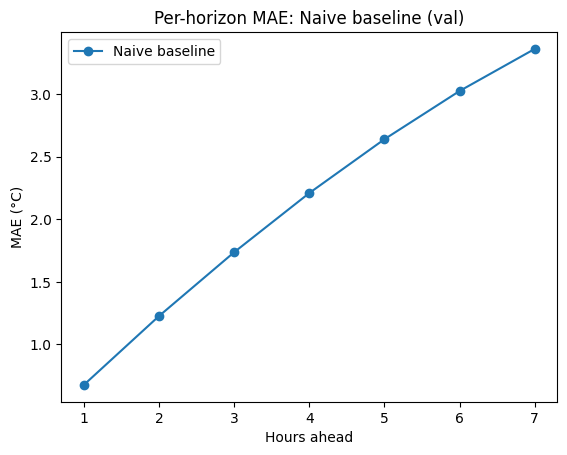

In [6]:
# --- Experiment 1: Naive baseline, per-horizon MAE (val set) ---
# Same as the book's evaluate_naive_method (Listing 13.9), kept per horizon.

def evaluate_naive_method(dataset):
    total_abs_err = np.zeros(horizon)
    samples_seen = 0
    for samples, targets in dataset:
        samples = samples.numpy()
        targets = targets.numpy().astype("float64")
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds[:, None] - targets), axis=0)
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

naive_per_horizon_mae = evaluate_naive_method(val_dataset)

naive_per_horizon_mae = evaluate_naive_method(val_dataset)

for h in range(horizon):
    print(f"Naive: +{h+1}hr val MAE: {naive_per_horizon_mae[h]:.3f}")
print(f"Naive: blended val MAE: {naive_per_horizon_mae.mean():.3f}")

for samples, targets in val_dataset.take(1):
    naive_last = samples[:, -1, 1].numpy() * std[1] + mean[1]
    print("\nExample (3 random val samples):")
    for i in range(3):
        print(f"\nSample {i}:")
        for h in range(horizon):
            actual = float(targets[i, h])
            print(f"  +{h+1}hr | pred: {naive_last[i]:.2f}°C, actual: {actual:.2f}°C, abs error: {abs(naive_last[i]-actual):.2f}")

plt.figure()
plt.plot(range(1, horizon + 1), naive_per_horizon_mae, marker="o", label="Naive baseline")
plt.xlabel("Hours ahead")
plt.ylabel("MAE (°C)")
plt.title("Per-horizon MAE: Naive baseline (val)")
plt.legend()
plt.show()

## Experiment 2 — Simple LSTM(16)

Epoch 1/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - loss: 62.2192 - mae: 5.8286 - val_loss: 23.8234 - val_mae: 3.4778
Epoch 2/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 16.8267 - mae: 2.9368 - val_loss: 10.7673 - val_mae: 2.3379
Epoch 3/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 9.4935 - mae: 2.2339 - val_loss: 6.8409 - val_mae: 1.9004
Epoch 4/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 6.2556 - mae: 1.8290 - val_loss: 4.8708 - val_mae: 1.6192
Epoch 5/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 4.6692 - mae: 1.5853 - val_loss: 3.9143 - val_mae: 1.4579
Epoch 6/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 3.9948 - mae: 1.4505 - val_loss: 3.6183 - val_mae: 1.3861
Epoch 7/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 3.4685 - mae: 1.3569 - val_loss: 3.2740 - val_mae: 1.3238
Epoch 8/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 3.1645 - mae: 1.2995 - val_loss: 3.0609 - val_mae: 1.2716
Epoch 9/30
819/819 ━━━━━━━━━━━━━━━━━

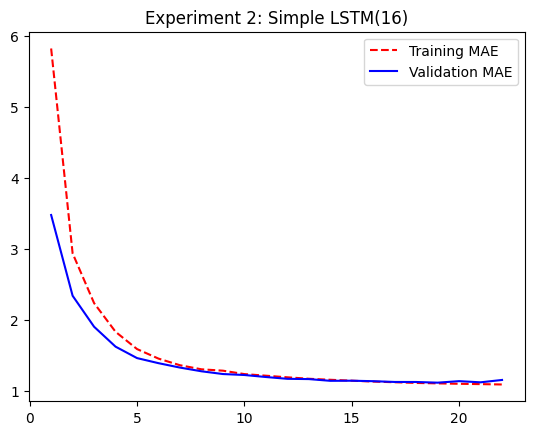

In [9]:
# --- Experiment 2: Simple LSTM(16). Book Listing 13.12, with Dense(horizon) ---
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(horizon)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/DATAX504/jena_lstm_v2.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks,
)

print("Experiment 2 (simple LSTM) — best val MAE:", min(history.history["val_mae"]))

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs_range = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs_range, loss, "r--", label="Training MAE")
plt.plot(epochs_range, val_loss, "b", label="Validation MAE")
plt.title("Experiment 2: Simple LSTM(16)")
plt.legend()
plt.show()

LSTM(16): +1hr val MAE: 0.530
LSTM(16): +2hr val MAE: 0.773
LSTM(16): +3hr val MAE: 0.993
LSTM(16): +4hr val MAE: 1.173
LSTM(16): +5hr val MAE: 1.316
LSTM(16): +6hr val MAE: 1.440
LSTM(16): +7hr val MAE: 1.552
LSTM(16): blended val MAE: 1.111


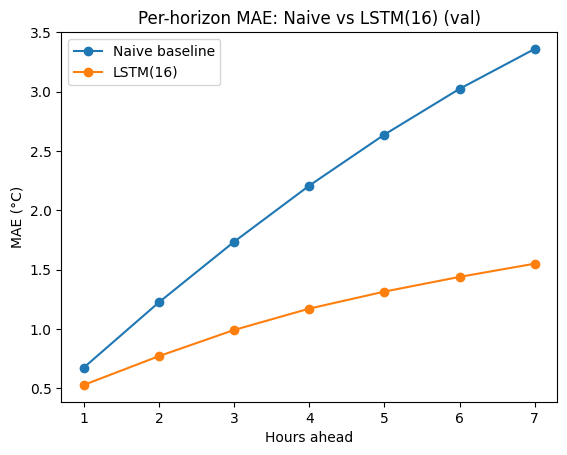

In [10]:
# --- Per-horizon MAE: Experiment 2 (val set) ---
def per_horizon_mae_model(model, dataset):
    total_abs_err = np.zeros(horizon)
    samples_seen = 0
    for samples, targets in dataset:
        preds = model.predict_on_batch(samples)
        total_abs_err += np.sum(np.abs(preds - targets.numpy()), axis=0)
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

lstm_per_horizon_mae = per_horizon_mae_model(model, val_dataset)

for h in range(horizon):
    print(f"LSTM(16): +{h+1}hr val MAE: {lstm_per_horizon_mae[h]:.3f}")
print(f"LSTM(16): blended val MAE: {lstm_per_horizon_mae.mean():.3f}")

plt.figure()
plt.plot(range(1, horizon + 1), naive_per_horizon_mae, marker="o", label="Naive baseline")
plt.plot(range(1, horizon + 1), lstm_per_horizon_mae, marker="o", label="LSTM(16)")
plt.xlabel("Hours ahead")
plt.ylabel("MAE (°C)")
plt.title("Per-horizon MAE: Naive vs LSTM(16) (val)")
plt.legend()
plt.show()

## Experiment 3 — LSTM(32) + Recurrent Dropout

Epoch 1/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 341s 412ms/step - loss: 43.8463 - mae: 4.7897 - val_loss: 12.0996 - val_mae: 2.5481
Epoch 2/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 336s 410ms/step - loss: 15.1841 - mae: 2.8978 - val_loss: 6.6894 - val_mae: 1.8795
Epoch 3/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 338s 413ms/step - loss: 12.0834 - mae: 2.5849 - val_loss: 5.2240 - val_mae: 1.6723
Epoch 4/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 341s 416ms/step - loss: 10.8121 - mae: 2.4411 - val_loss: 4.3706 - val_mae: 1.5302
Epoch 5/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 340s 415ms/step - loss: 10.0557 - mae: 2.3479 - val_loss: 3.8696 - val_mae: 1.4406
Epoch 6/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 356s 433ms/step - loss: 9.4654 - mae: 2.2803 - val_loss: 3.5040 - val_mae: 1.3679
Epoch 7/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 341s 416ms/step - loss: 9.0318 - mae: 2.2262 - val_loss: 3.4229 - val_mae: 1.3545
Epoch 8/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 346s 422ms/step - loss: 8.6924 - mae: 2.1842 - val_loss: 3.4098 - val_mae: 1.3397
Epoch 9/30
819/819

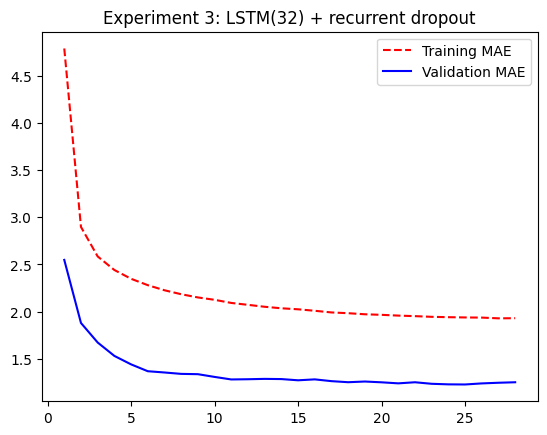

In [11]:
# --- Experiment 3: LSTM(32) + recurrent dropout. Book Listing 13.22, with Dense(horizon) ---
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)   # recurrent dropout disables the fast GPU path, so this is slow
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(horizon)(x)
model_dropout = keras.Model(inputs, outputs)

callbacks_dropout = [
    keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/DATAX504/jena_lstm_dropout_v2.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
]
model_dropout.compile(optimizer="adam", loss="mse", metrics=["mae"])
history_dropout = model_dropout.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks_dropout,
)

print("Experiment 3 (LSTM(32) + recurrent dropout) — best val MAE:", min(history_dropout.history["val_mae"]))

loss = history_dropout.history["mae"]
val_loss = history_dropout.history["val_mae"]
epochs_range = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs_range, loss, "r--", label="Training MAE")
plt.plot(epochs_range, val_loss, "b", label="Validation MAE")
plt.title("Experiment 3: LSTM(32) + recurrent dropout")
plt.legend()
plt.show()

LSTM(32)+rec. dropout: +1hr val MAE: 0.634
LSTM(32)+rec. dropout: +2hr val MAE: 0.862
LSTM(32)+rec. dropout: +3hr val MAE: 1.090
LSTM(32)+rec. dropout: +4hr val MAE: 1.284
LSTM(32)+rec. dropout: +5hr val MAE: 1.439
LSTM(32)+rec. dropout: +6hr val MAE: 1.573
LSTM(32)+rec. dropout: +7hr val MAE: 1.708
LSTM(32)+rec. dropout: blended val MAE: 1.227


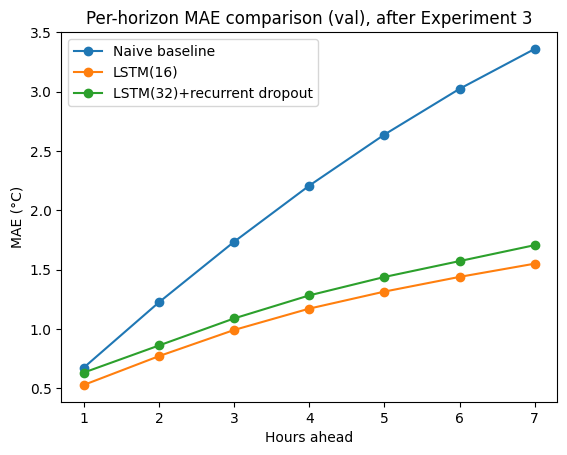

In [12]:
# --- Per-horizon MAE: Experiment 3 (val set) ---
dropout_per_horizon_mae = per_horizon_mae_model(model_dropout, val_dataset)

for h in range(horizon):
    print(f"LSTM(32)+rec. dropout: +{h+1}hr val MAE: {dropout_per_horizon_mae[h]:.3f}")
print(f"LSTM(32)+rec. dropout: blended val MAE: {dropout_per_horizon_mae.mean():.3f}")

plt.figure()
plt.plot(range(1, horizon + 1), naive_per_horizon_mae, marker="o", label="Naive baseline")
plt.plot(range(1, horizon + 1), lstm_per_horizon_mae, marker="o", label="LSTM(16)")
plt.plot(range(1, horizon + 1), dropout_per_horizon_mae, marker="o", label="LSTM(32)+recurrent dropout")
plt.xlabel("Hours ahead")
plt.ylabel("MAE (°C)")
plt.title("Per-horizon MAE comparison (val), after Experiment 3")
plt.legend()
plt.show()

## Experiment 4 — Stacked GRU(32,32) + Dropout

Epoch 1/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 615s 746ms/step - loss: 41.0139 - mae: 4.5333 - val_loss: 10.6147 - val_mae: 2.2366
Epoch 2/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 610s 745ms/step - loss: 12.8743 - mae: 2.6147 - val_loss: 5.9084 - val_mae: 1.7232
Epoch 3/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 610s 744ms/step - loss: 10.5886 - mae: 2.3960 - val_loss: 4.8427 - val_mae: 1.5998
Epoch 4/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 607s 741ms/step - loss: 9.7278 - mae: 2.3009 - val_loss: 4.1613 - val_mae: 1.4775
Epoch 5/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 609s 744ms/step - loss: 9.0421 - mae: 2.2207 - val_loss: 3.8007 - val_mae: 1.4323
Epoch 6/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 608s 742ms/step - loss: 8.6657 - mae: 2.1702 - val_loss: 3.5853 - val_mae: 1.3862
Epoch 7/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 619s 739ms/step - loss: 8.3208 - mae: 2.1265 - val_loss: 3.6521 - val_mae: 1.4039
Epoch 8/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 603s 736ms/step - loss: 7.9570 - mae: 2.0808 - val_loss: 3.3830 - val_mae: 1.3502
Epoch 9/30
819/819 ━

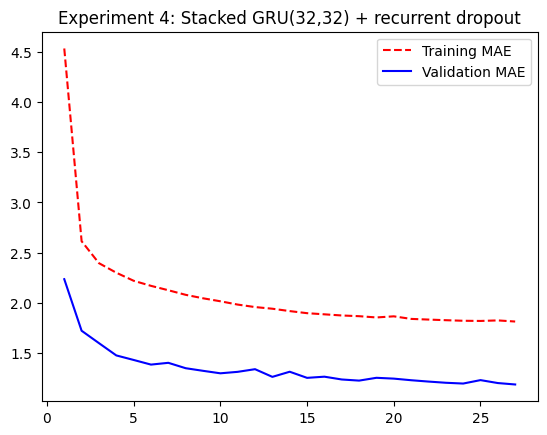

In [13]:
# --- Experiment 4: Stacked GRU(32,32) + recurrent dropout. Book Listing 13.23, with Dense(horizon) ---
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(horizon)(x)
model_stacked = keras.Model(inputs, outputs)

callbacks_stacked = [
    keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/DATAX504/jena_stacked_gru_v2.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
]
model_stacked.compile(optimizer="adam", loss="mse", metrics=["mae"])
history_stacked = model_stacked.fit(
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    callbacks=callbacks_stacked,
)

print("Experiment 4 (stacked GRU + recurrent dropout) — best val MAE:", min(history_stacked.history["val_mae"]))

loss = history_stacked.history["mae"]
val_loss = history_stacked.history["val_mae"]
epochs_range = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs_range, loss, "r--", label="Training MAE")
plt.plot(epochs_range, val_loss, "b", label="Validation MAE")
plt.title("Experiment 4: Stacked GRU(32,32) + recurrent dropout")
plt.legend()
plt.show()

Stacked GRU+rec. dropout: +1hr val MAE: 0.710
Stacked GRU+rec. dropout: +2hr val MAE: 0.853
Stacked GRU+rec. dropout: +3hr val MAE: 1.059
Stacked GRU+rec. dropout: +4hr val MAE: 1.243
Stacked GRU+rec. dropout: +5hr val MAE: 1.383
Stacked GRU+rec. dropout: +6hr val MAE: 1.502
Stacked GRU+rec. dropout: +7hr val MAE: 1.634
Stacked GRU+rec. dropout: blended val MAE: 1.197


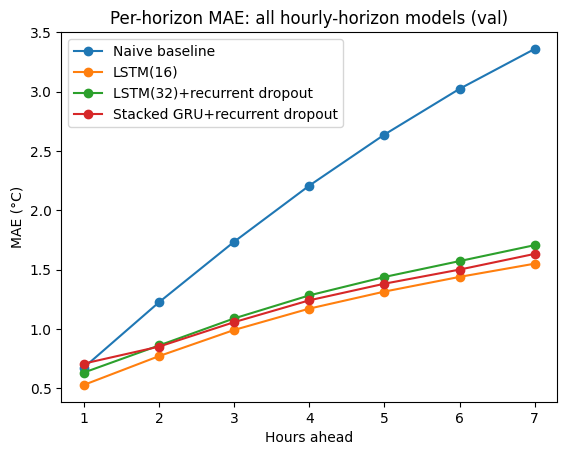

In [14]:
# --- Per-horizon MAE: Experiment 4 (val set) ---
stacked_per_horizon_mae = per_horizon_mae_model(model_stacked, val_dataset)

for h in range(horizon):
    print(f"Stacked GRU+rec. dropout: +{h+1}hr val MAE: {stacked_per_horizon_mae[h]:.3f}")
print(f"Stacked GRU+rec. dropout: blended val MAE: {stacked_per_horizon_mae.mean():.3f}")

plt.figure()
plt.plot(range(1, horizon + 1), naive_per_horizon_mae, marker="o", label="Naive baseline")
plt.plot(range(1, horizon + 1), lstm_per_horizon_mae, marker="o", label="LSTM(16)")
plt.plot(range(1, horizon + 1), dropout_per_horizon_mae, marker="o", label="LSTM(32)+recurrent dropout")
plt.plot(range(1, horizon + 1), stacked_per_horizon_mae, marker="o", label="Stacked GRU+recurrent dropout")
plt.xlabel("Hours ahead")
plt.ylabel("MAE (°C)")
plt.title("Per-horizon MAE: all hourly-horizon models (val)")
plt.legend()
plt.show()

## Experiment 2b — Simple LSTM(16) - daily (not hourly)
Done out of interest to compare.

samples shape: (256, 120, 14)
targets shape: (256, 7)
Epoch 1/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 60s 70ms/step - loss: 64.7781 - mae: 6.1858 - val_loss: 30.7589 - val_mae: 4.2508
Epoch 2/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 74s 63ms/step - loss: 25.0300 - mae: 3.8791 - val_loss: 22.2009 - val_mae: 3.6564
Epoch 3/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 20.8928 - mae: 3.5804 - val_loss: 21.2935 - val_mae: 3.5984
Epoch 4/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 60ms/step - loss: 20.1453 - mae: 3.5274 - val_loss: 20.9278 - val_mae: 3.5654
Epoch 5/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 65ms/step - loss: 19.2534 - mae: 3.4521 - val_loss: 21.0217 - val_mae: 3.5751
Epoch 6/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 19.1928 - mae: 3.4493 - val_loss: 21.0526 - val_mae: 3.5828
Epoch 7/30
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 18.2985 - mae: 3.3728 - val_loss: 21.2571 - val_mae: 3.6035
Experiment 2b (LSTM(16), daily horizon) — best val MAE: 3.565444231033325


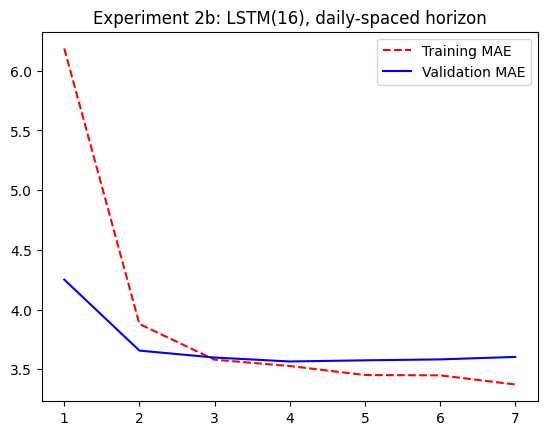

In [9]:
# --- Experiment 2b: LSTM(16), daily-spaced horizon (+24hr ... +168hr) ---
horizon_daily = 7
delay_daily = sampling_rate * (sequence_length + 24 * horizon_daily - 1)   # book's formula, furthest target = +168hr

n_daily = len(raw_data) - delay_daily
targets_daily = np.stack(
    [temperature[sampling_rate * (sequence_length + 24 * d - 1):][:n_daily] for d in range(1, horizon_daily + 1)],
    axis=1,
).astype("float32")   # shape (n_daily, 7): +24hr, +48hr, ..., +168hr

train_dataset_daily = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay_daily], targets=targets_daily,
    sampling_rate=sampling_rate, sequence_length=sequence_length,
    shuffle=True, batch_size=batch_size,
    start_index=0, end_index=num_train_samples,
)
val_dataset_daily = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay_daily], targets=targets_daily,
    sampling_rate=sampling_rate, sequence_length=sequence_length,
    shuffle=True, batch_size=batch_size,
    start_index=num_train_samples, end_index=num_train_samples + num_val_samples,
)
test_dataset_daily = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay_daily], targets=targets_daily,
    sampling_rate=sampling_rate, sequence_length=sequence_length,
    shuffle=True, batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

for samples, tgts in train_dataset_daily.take(1):
    print("samples shape:", samples.shape)   # expect (256, 120, 14)
    print("targets shape:", tgts.shape)      # expect (256, 7)

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(horizon_daily)(x)
model_2b = keras.Model(inputs, outputs)

callbacks_2b = [
    keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/DATAX504/jena_lstm_daily_v2.keras", save_best_only=True
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
]
model_2b.compile(optimizer="adam", loss="mse", metrics=["mae"])
history_2b = model_2b.fit(
    train_dataset_daily,
    epochs=30,
    validation_data=val_dataset_daily,
    callbacks=callbacks_2b,
)

print("Experiment 2b (LSTM(16), daily horizon) — best val MAE:", min(history_2b.history["val_mae"]))

loss = history_2b.history["mae"]
val_loss = history_2b.history["val_mae"]
epochs_range = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs_range, loss, "r--", label="Training MAE")
plt.plot(epochs_range, val_loss, "b", label="Validation MAE")
plt.title("Experiment 2b: LSTM(16), daily-spaced horizon")
plt.legend()
plt.show()

LSTM(16) daily: day 1 (+24hr) val MAE: 2.617
LSTM(16) daily: day 2 (+48hr) val MAE: 3.142
LSTM(16) daily: day 3 (+72hr) val MAE: 3.489
LSTM(16) daily: day 4 (+96hr) val MAE: 3.741
LSTM(16) daily: day 5 (+120hr) val MAE: 3.888
LSTM(16) daily: day 6 (+144hr) val MAE: 3.997
LSTM(16) daily: day 7 (+168hr) val MAE: 4.084
LSTM(16) daily: blended val MAE: 3.565


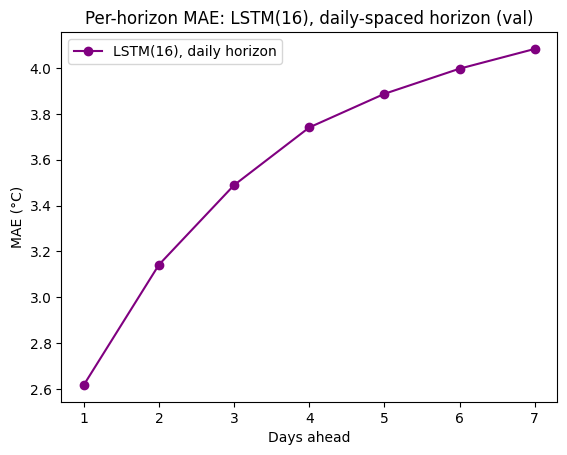

In [11]:
per_horizon_mae_2b = np.zeros(horizon_daily)
samples_seen = 0
for samples, targets in val_dataset_daily:
    preds = model_2b.predict_on_batch(samples)
    per_horizon_mae_2b += np.sum(np.abs(preds - targets.numpy()), axis=0)
    samples_seen += samples.shape[0]
per_horizon_mae_2b /= samples_seen

for d in range(1, horizon_daily + 1):
    print(f"LSTM(16) daily: day {d} (+{24*d}hr) val MAE: {per_horizon_mae_2b[d-1]:.3f}")
print(f"LSTM(16) daily: blended val MAE: {per_horizon_mae_2b.mean():.3f}")

plt.figure()
plt.plot(range(1, horizon_daily + 1), per_horizon_mae_2b, marker="o", color="purple", label="LSTM(16), daily horizon")
plt.xlabel("Days ahead")
plt.ylabel("MAE (°C)")
plt.title("Per-horizon MAE: LSTM(16), daily-spaced horizon (val)")
plt.legend()
plt.show()

**Validation MAE  (°C), hourly horizon**

| Model | +1hr | +2hr | +3hr | +4hr | +5hr | +6hr | +7hr | Blended |
|---|---|---|---|---|---|---|---|---|
| 1 Naive baseline | 0.676 | 1.226 | 1.736 | 2.209 | 2.639 | 3.025 | 3.361 | 2.125 |
| 2 LSTM(16) | **0.530** | **0.773** | **0.993** | **1.173** | **1.316** | **1.440** | **1.552** | **1.111** |
| 3 LSTM(32) + recurrent dropout | 0.634 | 0.862 | 1.090 | 1.284 | 1.439 | 1.573 | 1.708 | 1.227 |
| 4 Stacked GRU(32,32) + recurrent dropout | 0.710 | 0.853 | 1.059 | 1.243 | 1.383 | 1.502 | 1.634 | 1.197 |

**Validation MAE  (°C), daily horizon**

| Model | Day 1 (+24hr) | Day 2 (+48hr) | Day 3 (+72hr) | Day 4 (+96hr) | Day 5 (+120hr) | Day 6 (+144hr) | Day 7 (+168hr) | Blended |
|---|---|---|---|---|---|---|---|---|
| 2b LSTM(16) | 2.617 | 3.142 | 3.489 | 3.741 | 3.888 | 3.997 | 4.084 | 3.565 |


In [7]:
# --- Final test evaluation: Experiment 2, LSTM(16), hourly horizon ---
model = keras.models.load_model("/content/drive/MyDrive/DATAX504/jena_lstm_v2.keras")

per_horizon_test = np.zeros(horizon)
samples_seen = 0
for samples, targets in test_dataset:
    preds = model.predict_on_batch(samples)
    per_horizon_test += np.sum(np.abs(preds - targets.numpy()), axis=0)
    samples_seen += samples.shape[0]
per_horizon_test /= samples_seen
test_mae = per_horizon_test.mean()

for h in range(horizon):
    print(f"LSTM(16) test: +{h+1}hr MAE: {per_horizon_test[h]:.3f}")
print(f"\nLSTM(16) TEST MAE (Moodle a5_metric): {test_mae:.3f} °C")

LSTM(16) test: +1hr MAE: 0.553
LSTM(16) test: +2hr MAE: 0.805
LSTM(16) test: +3hr MAE: 1.033
LSTM(16) test: +4hr MAE: 1.224
LSTM(16) test: +5hr MAE: 1.382
LSTM(16) test: +6hr MAE: 1.523
LSTM(16) test: +7hr MAE: 1.654

LSTM(16) TEST MAE (Moodle a5_metric): 1.168 °C


**LSTM(16), hourly horizon — validation vs test MAE (°C)**

| Split | +1hr | +2hr | +3hr | +4hr | +5hr | +6hr | +7hr | Blended |
|---|---|---|---|---|---|---|---|---|
| Validation | 0.530 | 0.773 | 0.993 | 1.173 | 1.316 | 1.440 | 1.552 | 1.111 |
| Test | 0.553 | 0.805 | 1.033 | 1.224 | 1.382 | 1.523 | 1.654 | 1.168 |
| Gap (Test − Val) | +0.023 | +0.032 | +0.040 | +0.051 | +0.066 | +0.083 | +0.102 | +0.057 |

---
# Track B — Text (AG News)

Four-class news topic classification.

You decide: how to load AG News (TFDS or another source), vocabulary / sequence length, Embedding + LSTM / Transformer / other, and the train/val/test protocol.


In [ ]:
if TRACK == "B":
    # TODO: load AG News (or a documented subset)
    # TODO: text → integer sequences (TextVectorization, tokenizer, etc.)
    # TODO: define, compile, and fit a classifier for 4 classes
    # TODO: report test accuracy as a percentage for Moodle a5_metric
    #
    # metric = ...  # accuracy %
    metric = None
    print(f"Track B accuracy % (Moodle a5_metric): {metric}")
else:
    print("Skipping Track B")


---
## Written responses

### Architecture summary (Moodle `a5_architecture`, max 100 words)

I tried the following architectures and sizes on a window that was +1, +2 to + 7 hours ahead and also did a comparison out of interest on a +1, +2 ..+ 7 daily horizon.
I found that simple LSTM(16) performed best in terms of validation MAE.
Looking at the LSTM(16) train/validation chart, there is no evidence of overfitting, so regularisation in the later models does not seem to help. As we are forecasting only a few hours ahead, the simple model is also able to predict accurately so no need for a deeper model or regularisation.
This contrasts with the book's +24 hour horizon, where the plain LSTM(16) showed overfitting and the deeper, more regularised models performed better - probably because predicting 24 hours ahead vs 1 hour ahead is harder.

**Validation MAE  (°C), hourly horizon**

| Model | +1hr | +2hr | +3hr | +4hr | +5hr | +6hr | +7hr | Blended |
|---|---|---|---|---|---|---|---|---|
| 1 Naive baseline | 0.676 | 1.226 | 1.736 | 2.209 | 2.639 | 3.025 | 3.361 | 2.125 |
| 2 LSTM(16) | **0.530** | **0.773** | **0.993** | **1.173** | **1.316** | **1.440** | **1.552** | **1.111** |
| 3 LSTM(32) + recurrent dropout | 0.634 | 0.862 | 1.090 | 1.284 | 1.439 | 1.573 | 1.708 | 1.227 |
| 4 Stacked GRU(32,32) + recurrent dropout | 0.710 | 0.853 | 1.059 | 1.243 | 1.383 | 1.502 | 1.634 | 1.197 |

**Validation MAE  (°C), daily horizon**

| Model | Day 1 (+24hr) | Day 2 (+48hr) | Day 3 (+72hr) | Day 4 (+96hr) | Day 5 (+120hr) | Day 6 (+144hr) | Day 7 (+168hr) | Blended |
|---|---|---|---|---|---|---|---|---|
| 2b LSTM(16) | 2.617 | 3.142 | 3.489 | 3.741 | 3.888 | 3.997 | 4.084 | 3.565 |

### Input preparation (Moodle `a5_tokenisation`, max 100 words)

Followed the textbook's method (chapter 13) , except for the horizon:

- Loaded the 420,451 rows in chronological order
- Kept all 14 features as input; raw temperature kept separately as the target
- Split 50% train / 25% val / 25% test, by time
- Normalised each feature using training data mean and standard deviation only
- Built windows with Keras's timeseries_dataset_from_array
- Target: temperature at +1 to +7 hours ahead, instead of the book's single +24 hour target
